# Mathematical Image Processing from Scratch

### A mathematical and computational study of digital image processing

This project implements fundamental image-processing techniques from scratch
using matrix operations, discrete convolution, finite differences, gradients,
thresholding, mathematical morphology, connected-component analysis, and
geometric feature extraction.

The objective is to understand the mathematical principles underlying
classical image processing rather than relying on high-level image-processing
libraries.

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving cat.jpg to cat.jpg


Image size: (3568, 2676)
Image mode: RGB


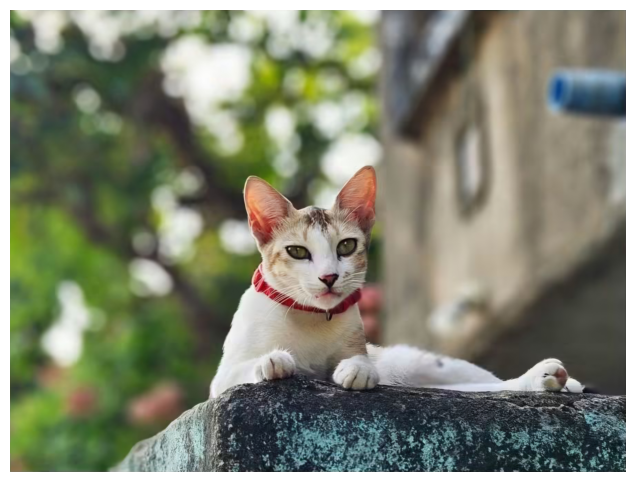

In [ ]:

image = Image.open(next(iter(uploaded)))

print("Image size:", image.size)
print("Image mode:", image.mode)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:

img_array = np.array(image)

print("Array shape:", img_array.shape)
print("Data type:", img_array.dtype)
print("Minimum pixel value:", img_array.min())
print("Maximum pixel value:", img_array.max())

Array shape: (2676, 3568, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [ ]:
print("Pixel at (100, 100):", img_array[100, 100])

In [ ]:

R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

print("R shape:", R.shape)
print("G shape:", G.shape)
print("B shape:", B.shape)

R shape: (2676, 3568)
G shape: (2676, 3568)
B shape: (2676, 3568)


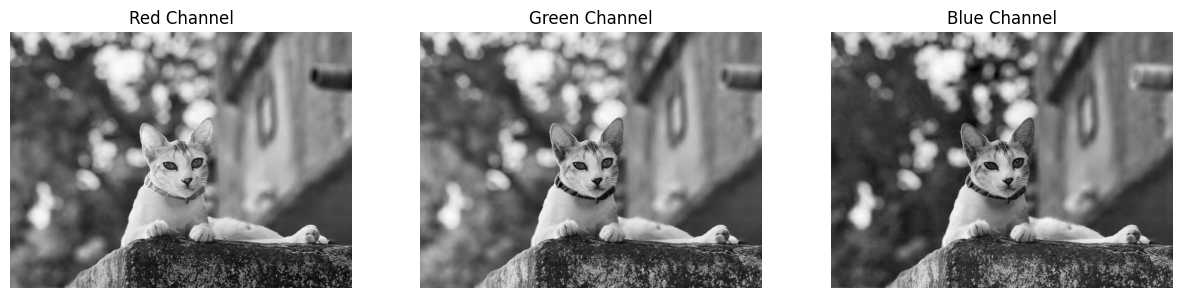

In [ ]:

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(R, cmap="gray")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(G, cmap="gray")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(B, cmap="gray")
plt.title("Blue Channel")
plt.axis("off")

plt.show()

In [ ]:

gray = 0.299 * R + 0.587 * G + 0.114 * B

print("Grayscale shape:", gray.shape)
print("Data type:", gray.dtype)
print("Minimum:", gray.min())
print("Maximum:", gray.max())

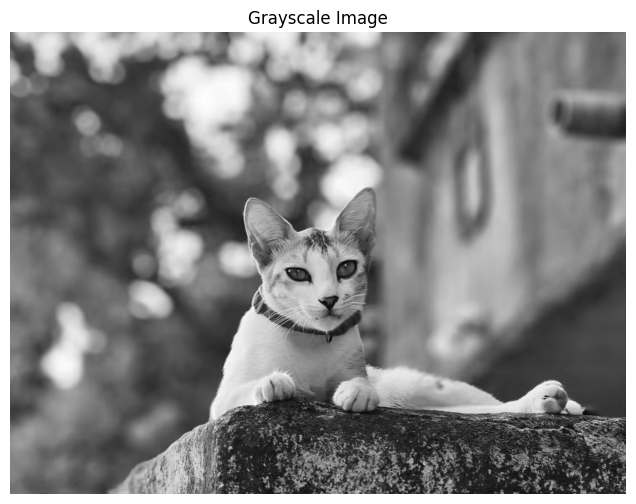

In [ ]:

plt.figure(figsize=(8, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

In [ ]:
print(gray[:5, :5])

In [ ]:

gray_uint8 = np.clip(gray, 0, 255).astype(np.uint8)

print("Data type:", gray_uint8.dtype)
print("Minimum:", gray_uint8.min())
print("Maximum:", gray_uint8.max())

In [ ]:

small_image = np.array([
    [10, 20, 30],
    [40, 50, 60],
    [70, 80, 90]
], dtype=float)

kernel = np.ones((3, 3)) / 9

result = np.sum(small_image * kernel)

print("Result:", result)

In [ ]:

def apply_kernel(image, kernel):
    kernel_height, kernel_width = kernel.shape
    image_height, image_width = image.shape

    output = np.zeros_like(image, dtype=float)

    pad_h = kernel_height // 2
    pad_w = kernel_width // 2

    padded = np.pad(
        image,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode="edge"
    )

    for i in range(image_height):
        for j in range(image_width):

            region = padded[
                i:i + kernel_height,
                j:j + kernel_width
            ]

            output[i, j] = np.sum(region * kernel)

    return output

In [ ]:

def apply_kernel(image, kernel):
    kernel_height, kernel_width = kernel.shape
    image_height, image_width = image.shape

    output = np.zeros_like(image, dtype=float)

    pad_h = kernel_height // 2
    pad_w = kernel_width // 2

    padded = np.pad(
        image,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode="edge"
    )

    for i in range(image_height):
        for j in range(image_width):

            region = padded[
                i:i + kernel_height,
                j:j + kernel_width
            ]

            output[i, j] = np.sum(region * kernel)

    return output

In [ ]:

blur_kernel = np.ones((3, 3)) / 9

blurred = apply_kernel(gray_uint8, blur_kernel)

blurred = np.clip(blurred, 0, 255).astype(np.uint8)

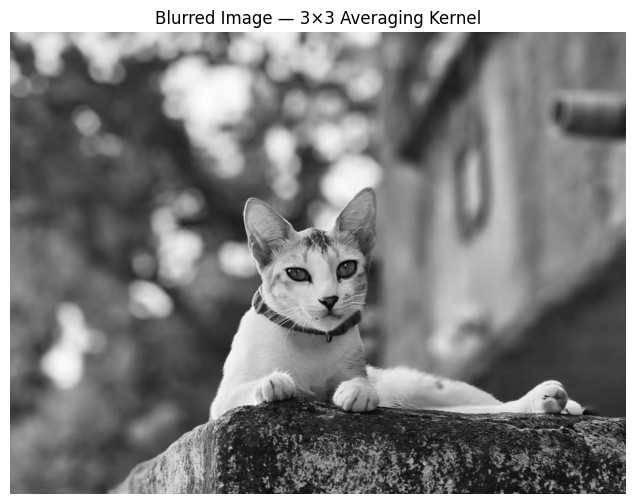

In [ ]:

plt.figure(figsize=(8, 6))
plt.imshow(blurred, cmap="gray")
plt.title("Blurred Image — 3×3 Averaging Kernel")
plt.axis("off")
plt.show()

In [ ]:

blur_3 = apply_kernel(
    gray_uint8,
    np.ones((3, 3)) / 9
)

blur_5 = apply_kernel(
    gray_uint8,
    np.ones((5, 5)) / 25
)

blur_9 = apply_kernel(
    gray_uint8,
    np.ones((9, 9)) / 81
)

blur_3 = np.clip(blur_3, 0, 255).astype(np.uint8)
blur_5 = np.clip(blur_5, 0, 255).astype(np.uint8)
blur_9 = np.clip(blur_9, 0, 255).astype(np.uint8)

In [ ]:

small_gray = np.array(
    Image.fromarray(gray_uint8).resize((800, 600))
)

print("New image shape:", small_gray.shape)

In [ ]:

blur_3 = apply_kernel(
    small_gray,
    np.ones((3, 3)) / 9
)

blur_5 = apply_kernel(
    small_gray,
    np.ones((5, 5)) / 25
)

blur_9 = apply_kernel(
    small_gray,
    np.ones((9, 9)) / 81
)

blur_3 = np.clip(blur_3, 0, 255).astype(np.uint8)
blur_5 = np.clip(blur_5, 0, 255).astype(np.uint8)
blur_9 = np.clip(blur_9, 0, 255).astype(np.uint8)

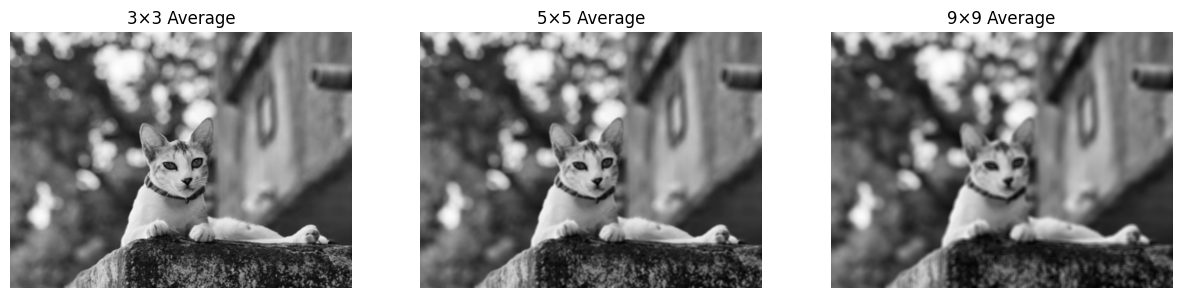

In [ ]:

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(blur_3, cmap="gray")
plt.title("3×3 Average")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blur_5, cmap="gray")
plt.title("5×5 Average")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blur_9, cmap="gray")
plt.title("9×9 Average")
plt.axis("off")

plt.show()

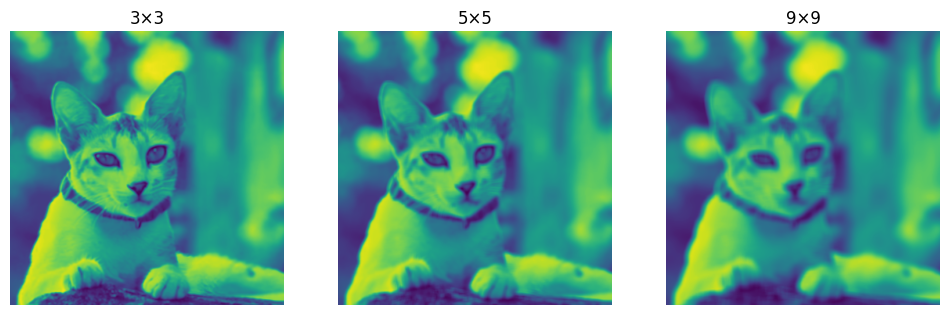

In [ ]:

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(blur_3)
plt.xlim(250, 600)
plt.ylim(500, 150)
plt.title("3×3")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blur_5)
plt.xlim(250, 600)
plt.ylim(500, 150)
plt.title("5×5")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blur_9)
plt.xlim(250, 600)
plt.ylim(500, 150)
plt.title("9×9")
plt.axis("off")

plt.show()

In [ ]:

sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=float)

sharpened = apply_kernel(small_gray, sharpen_kernel)

sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

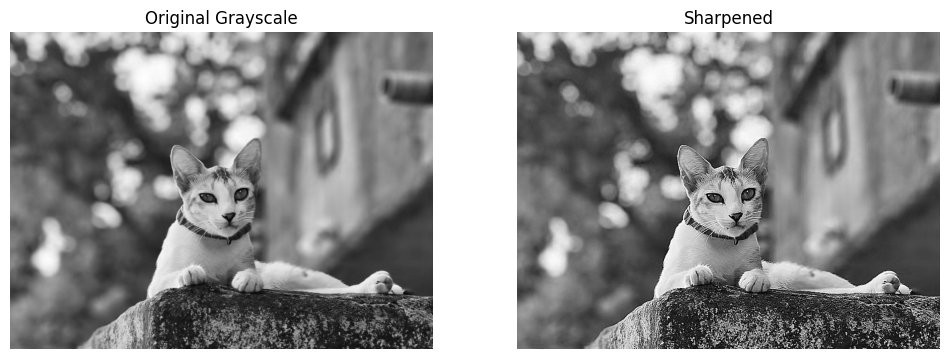

In [ ]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(small_gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sharpened, cmap="gray")
plt.title("Sharpened")
plt.axis("off")

plt.show()

In [ ]:

sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=float)

sobel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
], dtype=float)

Gx = apply_kernel(small_gray, sobel_x)
Gy = apply_kernel(small_gray, sobel_y)

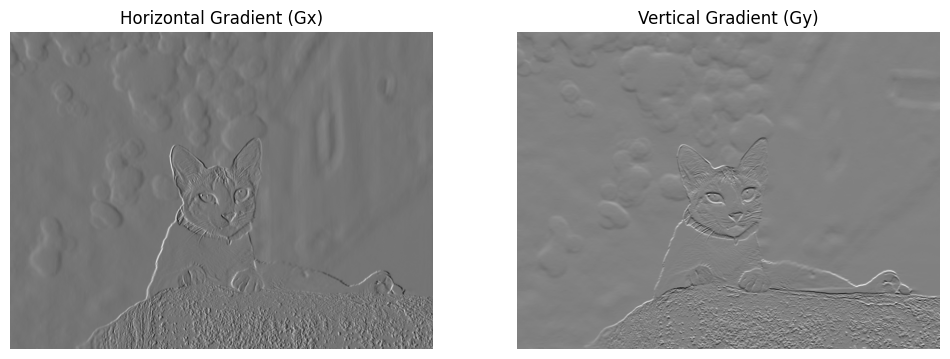

In [ ]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(Gx, cmap="gray")
plt.title("Horizontal Gradient (Gx)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(Gy, cmap="gray")
plt.title("Vertical Gradient (Gy)")
plt.axis("off")

plt.show()

In [ ]:

gradient_magnitude = np.sqrt(Gx**2 + Gy**2)

print("Minimum:", gradient_magnitude.min())
print("Maximum:", gradient_magnitude.max())

Minimum: 0.0
Maximum: 725.0337923159168


In [ ]:

gradient_display = (
    255 * gradient_magnitude / gradient_magnitude.max()
).astype(np.uint8)

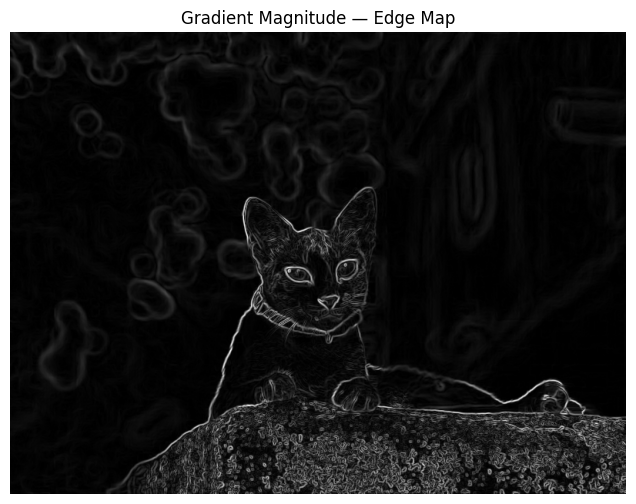

In [ ]:

plt.figure(figsize=(8, 6))
plt.imshow(gradient_display, cmap="gray")
plt.title("Gradient Magnitude — Edge Map")
plt.axis("off")
plt.show()

In [ ]:

threshold = 80

edges = np.where(
    gradient_magnitude > threshold,
    255,
    0
).astype(np.uint8)

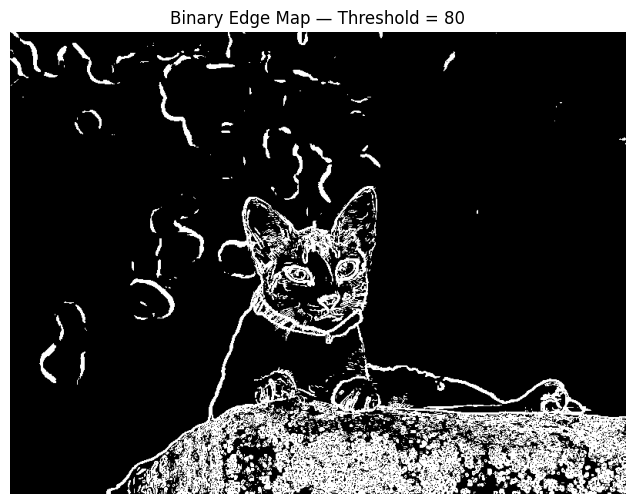

In [ ]:

plt.figure(figsize=(8, 6))
plt.imshow(edges, cmap="gray")
plt.title(f"Binary Edge Map — Threshold = {threshold}")
plt.axis("off")
plt.show()

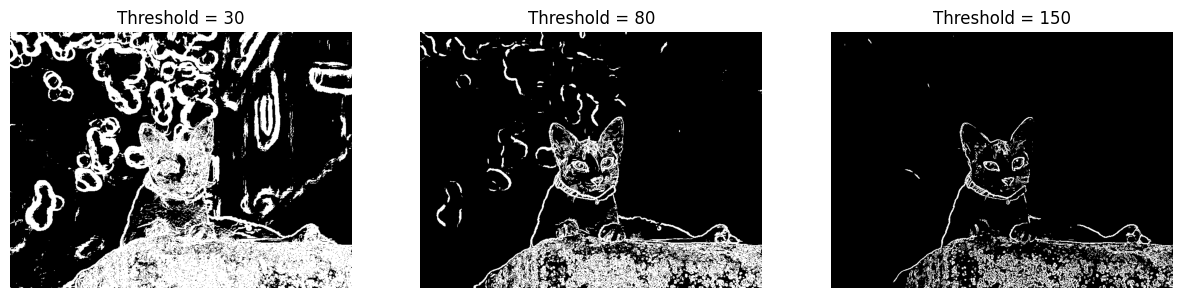

In [ ]:

thresholds = [30, 80, 150]

plt.figure(figsize=(15, 5))

for i, threshold in enumerate(thresholds):

    edges = np.where(
        gradient_magnitude > threshold,
        255,
        0
    ).astype(np.uint8)

    plt.subplot(1, 3, i + 1)
    plt.imshow(edges, cmap="gray")
    plt.title(f"Threshold = {threshold}")
    plt.axis("off")

plt.show()

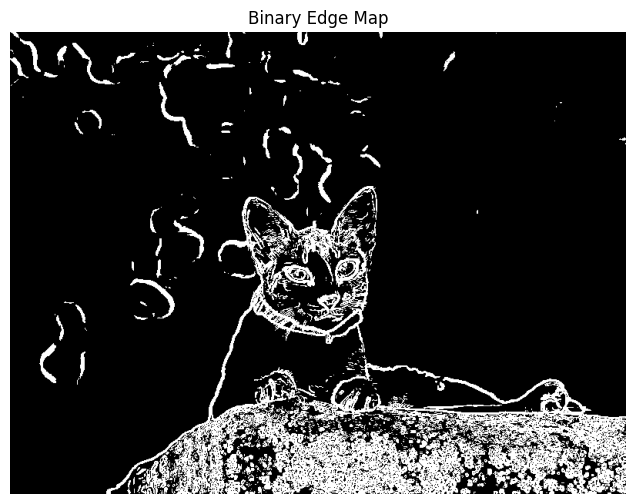

In [ ]:

threshold = 80

edges = np.where(
    gradient_magnitude > threshold,
    1,
    0
).astype(np.uint8)

plt.figure(figsize=(8, 6))
plt.imshow(edges, cmap="gray")
plt.title("Binary Edge Map")
plt.axis("off")
plt.show()

In [ ]:

from collections import deque

def connected_components(binary_image):
    height, width = binary_image.shape

    labels = np.zeros((height, width), dtype=int)
    label = 0

    neighbours = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),           (0, 1),
        (1, -1),  (1, 0),  (1, 1)
    ]

    for i in range(height):
        for j in range(width):

            if binary_image[i, j] == 1 and labels[i, j] == 0:

                label += 1
                queue = deque([(i, j)])
                labels[i, j] = label

                while queue:
                    x, y = queue.popleft()

                    for dx, dy in neighbours:
                        nx, ny = x + dx, y + dy

                        if (
                            0 <= nx < height and
                            0 <= ny < width and
                            binary_image[nx, ny] == 1 and
                            labels[nx, ny] == 0
                        ):
                            labels[nx, ny] = label
                            queue.append((nx, ny))

    return labels, label

In [ ]:

labels, num_components = connected_components(edges)

print("Number of connected components:", num_components)

Number of connected components: 571


In [ ]:

component_sizes = np.bincount(labels.ravel())

# Ignore label 0 (background)
component_sizes = component_sizes[1:]

print("Total components:", len(component_sizes))
print("Largest component:", component_sizes.max(), "pixels")
print("Smallest component:", component_sizes.min(), "pixels")

Total components: 571
Largest component: 51680 pixels
Smallest component: 1 pixels


In [ ]:

min_size = 100

filtered_labels = labels.copy()

for label in range(1, num_components + 1):
    if np.sum(labels == label) < min_size:
        filtered_labels[labels == label] = 0

remaining = len(
    np.unique(filtered_labels)
) - 1

print("Components remaining:", remaining)

Components remaining: 32


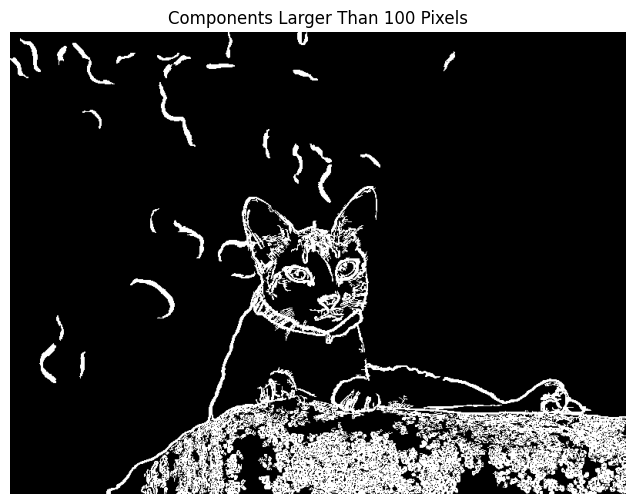

In [ ]:

plt.figure(figsize=(8, 6))
plt.imshow(filtered_labels > 0, cmap="gray")
plt.title(f"Components Larger Than {min_size} Pixels")
plt.axis("off")
plt.show()

In [ ]:

component_features = []

for label in range(1, num_components + 1):

    coords = np.argwhere(filtered_labels == label)

    if len(coords) == 0:
        continue

    y_coords = coords[:, 0]
    x_coords = coords[:, 1]

    area = len(coords)

    centroid_y = y_coords.mean()
    centroid_x = x_coords.mean()

    x_min, x_max = x_coords.min(), x_coords.max()
    y_min, y_max = y_coords.min(), y_coords.max()

    width = x_max - x_min + 1
    height = y_max - y_min + 1

    aspect_ratio = width / height

    component_features.append({
        "label": label,
        "area": area,
        "centroid_x": centroid_x,
        "centroid_y": centroid_y,
        "width": width,
        "height": height,
        "aspect_ratio": aspect_ratio
    })

print("Measured components:", len(component_features))

Measured components: 32


In [ ]:

import pandas as pd

features_df = pd.DataFrame(component_features)

features_df = features_df.sort_values(
    "area",
    ascending=False
)

features_df.head(10)

,label,area,centroid_x,centroid_y,width,height,aspect_ratio
20,82,51680,485.597910,494.622775,675,400,1.687500
31,471,831,190.783394,577.554753,37,51,0.725490
13,45,555,213.774775,109.735135,48,84,0.571429
24,194,496,192.614919,339.401210,58,52,1.115385
26,242,385,48.488312,429.768831,22,52,0.423077
22,121,378,235.494709,264.621693,40,50,0.800000
3,8,376,103.180851,43.164894,55,54,1.018519
19,78,336,408.419643,196.625000,18,50,0.360000
2,7,277,29.299639,28.263538,27,44,0.613636
28,260,273,364.813187,451.857143,60,39,1.538462


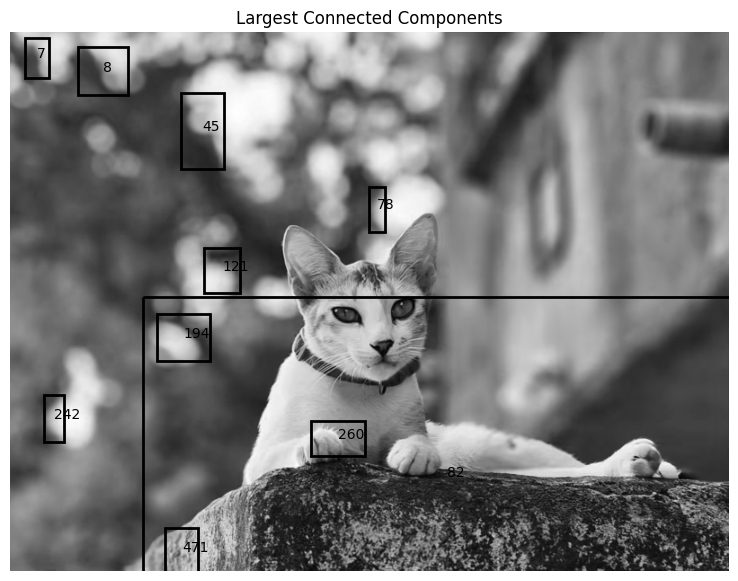

In [ ]:

fig, ax = plt.subplots(figsize=(10, 7))

ax.imshow(small_gray, cmap="gray")

# Show the 10 largest components
for _, row in features_df.head(10).iterrows():

    x = row["centroid_x"]
    y = row["centroid_y"]

    width = row["width"]
    height = row["height"]

    x_min = x - width / 2
    y_min = y - height / 2

    rectangle = plt.Rectangle(
        (x_min, y_min),
        width,
        height,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rectangle)

    ax.text(
        x,
        y,
        str(int(row["label"])),
        fontsize=10
    )

ax.set_title("Largest Connected Components")
ax.axis("off")

plt.show()

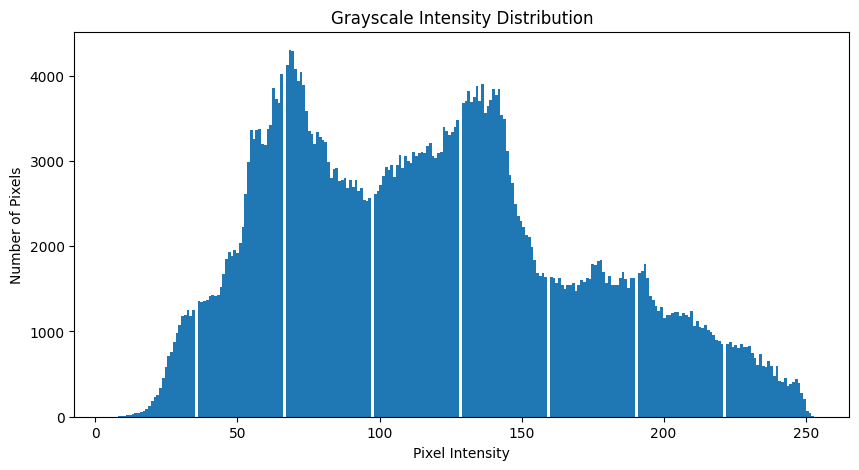

In [ ]:

plt.figure(figsize=(10, 5))

plt.hist(
    small_gray.ravel(),
    bins=256
)

plt.title("Grayscale Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")

plt.show()

In [ ]:

def otsu_threshold(image):
    histogram = np.bincount(image.ravel(), minlength=256)

    total_pixels = image.size
    total_sum = np.sum(
        np.arange(256) * histogram
    )

    weight_background = 0
    sum_background = 0

    maximum_variance = 0
    best_threshold = 0

    for threshold in range(256):

        weight_background += histogram[threshold]
        sum_background += threshold * histogram[threshold]

        if weight_background == 0:
            continue

        weight_foreground = total_pixels - weight_background

        if weight_foreground == 0:
            break

        mean_background = (
            sum_background / weight_background
        )

        mean_foreground = (
            (total_sum - sum_background)
            / weight_foreground
        )

        between_variance = (
            weight_background / total_pixels
            * weight_foreground / total_pixels
            * (mean_background - mean_foreground) ** 2
        )

        if between_variance > maximum_variance:
            maximum_variance = between_variance
            best_threshold = threshold

    return best_threshold

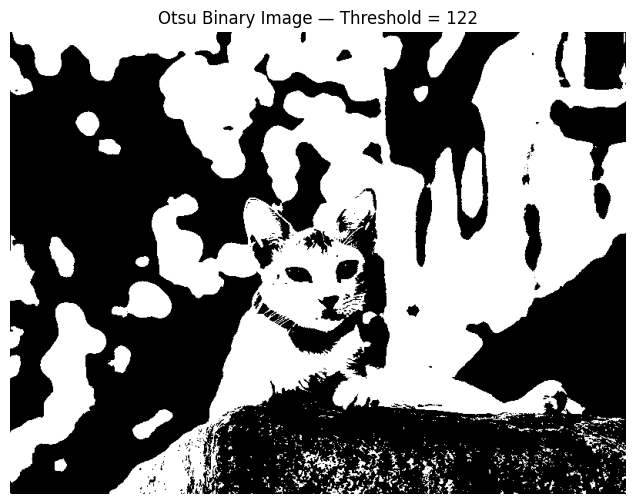

In [ ]:

otsu_binary = np.where(
    small_gray > otsu_T,
    255,
    0
).astype(np.uint8)

plt.figure(figsize=(8, 6))
plt.imshow(otsu_binary, cmap="gray")
plt.title(f"Otsu Binary Image — Threshold = {otsu_T}")
plt.axis("off")
plt.show()

Otsu threshold: 122


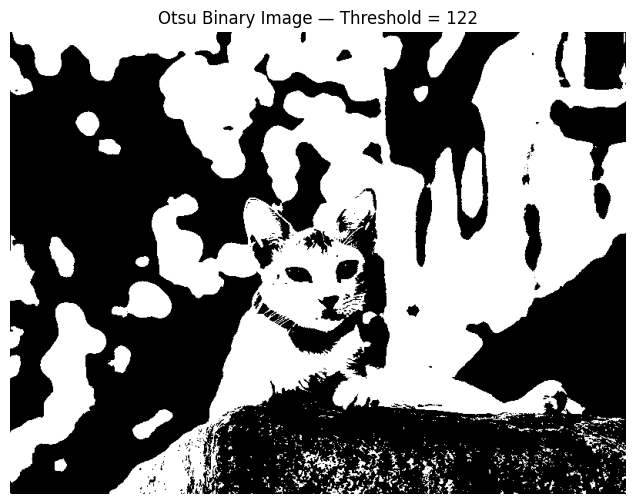

In [ ]:

def otsu_threshold(image):
    histogram = np.bincount(image.ravel(), minlength=256)

    total_pixels = image.size
    total_sum = np.sum(np.arange(256) * histogram)

    weight_background = 0
    sum_background = 0

    maximum_variance = 0
    best_threshold = 0

    for threshold in range(256):

        weight_background += histogram[threshold]
        sum_background += threshold * histogram[threshold]

        if weight_background == 0:
            continue

        weight_foreground = total_pixels - weight_background

        if weight_foreground == 0:
            break

        mean_background = sum_background / weight_background
        mean_foreground = (
            (total_sum - sum_background)
            / weight_foreground
        )

        between_variance = (
            (weight_background / total_pixels)
            * (weight_foreground / total_pixels)
            * (mean_background - mean_foreground) ** 2
        )

        if between_variance > maximum_variance:
            maximum_variance = between_variance
            best_threshold = threshold

    return best_threshold


# Calculate the threshold
otsu_T = otsu_threshold(small_gray)

print("Otsu threshold:", otsu_T)


# Create binary image
otsu_binary = np.where(
    small_gray > otsu_T,
    255,
    0
).astype(np.uint8)


# Display
plt.figure(figsize=(8, 6))
plt.imshow(otsu_binary, cmap="gray")
plt.title(f"Otsu Binary Image — Threshold = {otsu_T}")
plt.axis("off")
plt.show()

In [ ]:

otsu_binary_01 = (otsu_binary > 0).astype(np.uint8)

otsu_labels, otsu_num_components = connected_components(otsu_binary_01)

print("Connected components:", otsu_num_components)

Connected components: 706


In [ ]:

otsu_sizes = np.bincount(otsu_labels.ravel())

print("Largest component:", otsu_sizes[1:].max(), "pixels")
print("Number of components larger than 1000 pixels:",
      np.sum(otsu_sizes[1:] > 1000))

Largest component: 186037 pixels
Number of components larger than 1000 pixels: 7


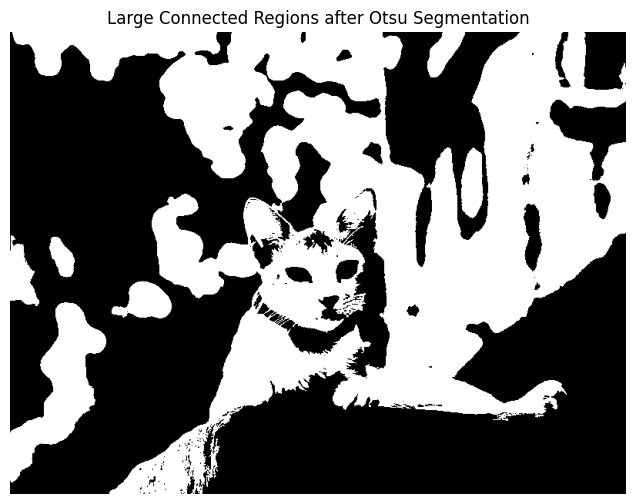

In [ ]:

large_otsu = np.zeros_like(otsu_binary_01)

for label in range(1, otsu_num_components + 1):
    if otsu_sizes[label] > 1000:
        large_otsu[otsu_labels == label] = 1

plt.figure(figsize=(8, 6))
plt.imshow(large_otsu, cmap="gray")
plt.title("Large Connected Regions after Otsu Segmentation")
plt.axis("off")
plt.show()

In [ ]:

def dilate(binary_image, kernel_size=3):
    pad = kernel_size // 2

    padded = np.pad(
        binary_image,
        pad,
        mode="constant",
        constant_values=0
    )

    output = np.zeros_like(binary_image)

    for i in range(binary_image.shape[0]):
        for j in range(binary_image.shape[1]):

            region = padded[
                i:i + kernel_size,
                j:j + kernel_size
            ]

            if np.any(region == 1):
                output[i, j] = 1

    return output

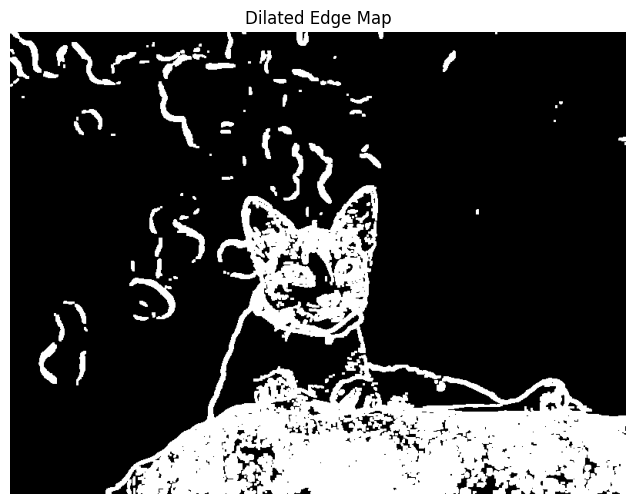

In [ ]:

dilated_edges = dilate(edges, kernel_size=3)

plt.figure(figsize=(8, 6))
plt.imshow(dilated_edges, cmap="gray")
plt.title("Dilated Edge Map")
plt.axis("off")
plt.show()

In [ ]:

dilated_labels, dilated_count = connected_components(dilated_edges)

print("Original components:", num_components)
print("After dilation:", dilated_count)

Original components: 571
After dilation: 114


In [ ]:

def erode(binary_image, kernel_size=3):
    pad = kernel_size // 2

    padded = np.pad(
        binary_image,
        pad,
        mode="constant",
        constant_values=0
    )

    output = np.zeros_like(binary_image)

    for i in range(binary_image.shape[0]):
        for j in range(binary_image.shape[1]):

            region = padded[
                i:i + kernel_size,
                j:j + kernel_size
            ]

            if np.all(region == 1):
                output[i, j] = 1

    return output

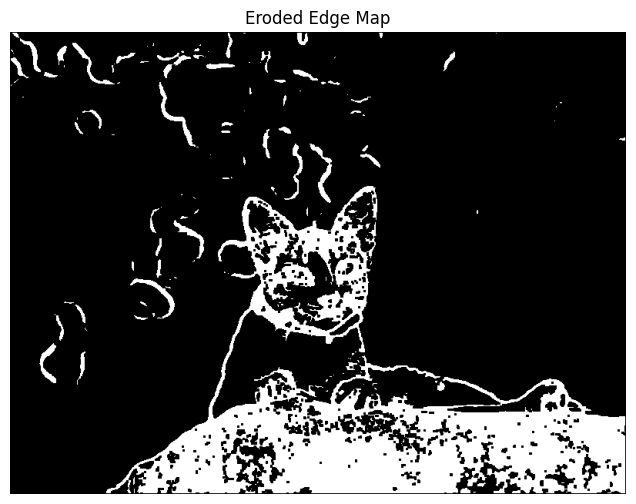

In [ ]:

eroded_edges = erode(dilated_edges, kernel_size=3)

plt.figure(figsize=(8, 6))
plt.imshow(eroded_edges, cmap="gray")
plt.title("Eroded Edge Map")
plt.axis("off")
plt.show()

In [ ]:

eroded_labels, eroded_count = connected_components(eroded_edges)

print("After dilation:", dilated_count)
print("After erosion:", eroded_count)

After dilation: 114
After erosion: 185


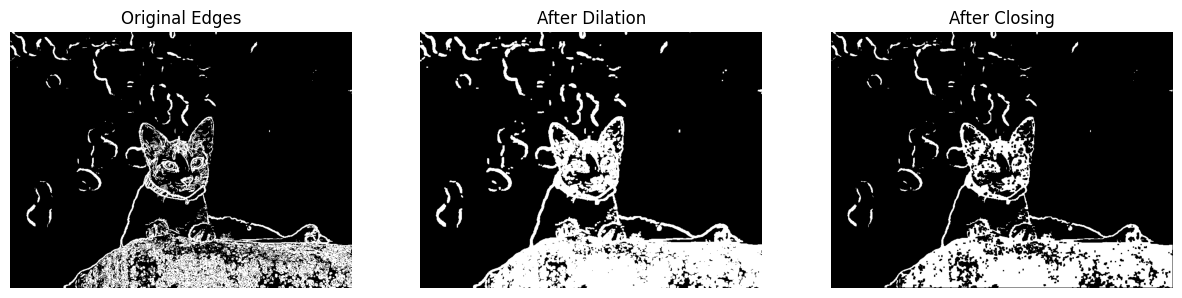

In [ ]:

closed_edges = erode(
    dilate(edges, kernel_size=3),
    kernel_size=3
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(edges, cmap="gray")
plt.title("Original Edges")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(dilated_edges, cmap="gray")
plt.title("After Dilation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(closed_edges, cmap="gray")
plt.title("After Closing")
plt.axis("off")

plt.show()

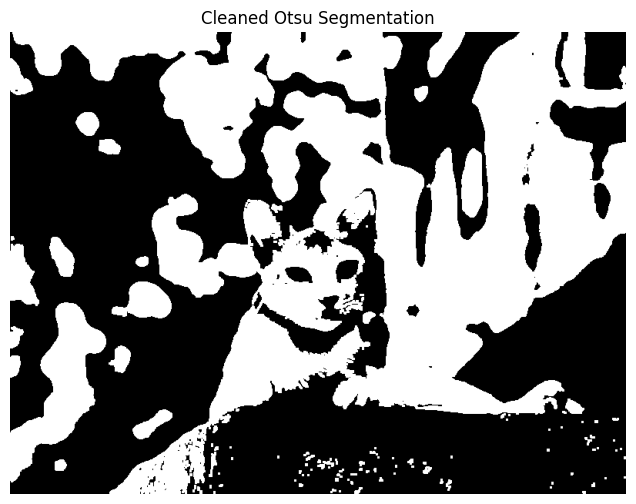

In [ ]:

# Convert Otsu result to binary 0/1
segmentation = (otsu_binary > 0).astype(np.uint8)

# Remove small noise with opening
clean_segmentation = dilate(
    erode(segmentation, kernel_size=3),
    kernel_size=3
)

plt.figure(figsize=(8, 6))
plt.imshow(clean_segmentation, cmap="gray")
plt.title("Cleaned Otsu Segmentation")
plt.axis("off")
plt.show()

In [ ]:

seg_labels, seg_count = connected_components(clean_segmentation)

print("Connected regions:", seg_count)

Connected regions: 102


In [ ]:

seg_sizes = np.bincount(seg_labels.ravel())

print("Largest region:", seg_sizes[1:].max(), "pixels")

Largest region: 183794 pixels


In [ ]:

seg_features = []

for label in range(1, seg_count + 1):

    coords = np.argwhere(seg_labels == label)

    if len(coords) == 0:
        continue

    y_coords = coords[:, 0]
    x_coords = coords[:, 1]

    area = len(coords)

    centroid_x = x_coords.mean()
    centroid_y = y_coords.mean()

    x_min, x_max = x_coords.min(), x_coords.max()
    y_min, y_max = y_coords.min(), y_coords.max()

    width = x_max - x_min + 1
    height = y_max - y_min + 1

    aspect_ratio = width / height

    seg_features.append({
        "label": label,
        "area": area,
        "centroid_x": centroid_x,
        "centroid_y": centroid_y,
        "width": width,
        "height": height,
        "aspect_ratio": aspect_ratio
    })

seg_df = pd.DataFrame(seg_features)

seg_df = seg_df.sort_values(
    "area",
    ascending=False
)

seg_df.head(10)

,label,area,centroid_x,centroid_y,width,height,aspect_ratio
0,1,183794,467.893979,236.115874,797,600,1.328333
17,18,11459,64.468715,461.151584,125,234,0.534188
14,15,2405,175.925156,350.125156,78,48,1.625000
6,7,2031,599.972920,196.807976,28,90,0.311111
12,13,2000,14.076500,318.280500,38,81,0.469136
1,2,1589,562.602895,25.644430,49,59,0.830508
10,11,1086,67.202578,292.186004,33,52,0.634615
23,24,904,183.652655,509.251106,52,39,1.333333
2,3,847,10.781582,62.502952,30,48,0.625000
4,5,717,100.648536,118.405858,31,31,1.000000


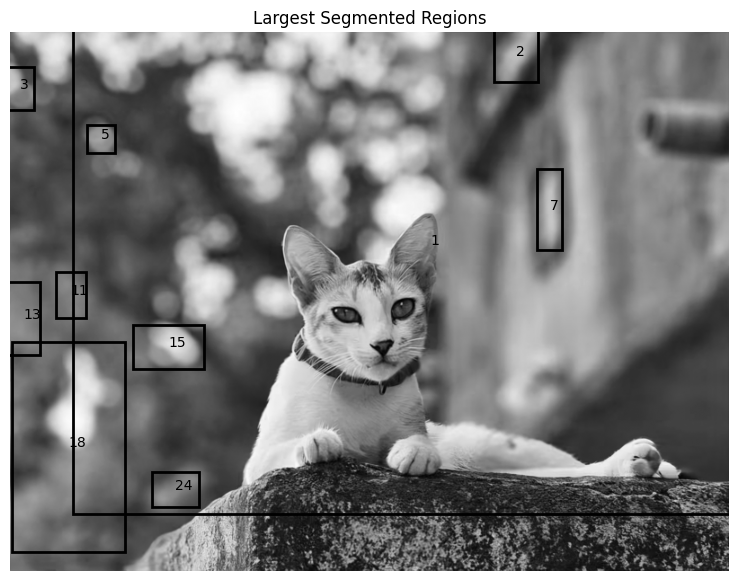

In [ ]:

fig, ax = plt.subplots(figsize=(10, 7))

ax.imshow(small_gray, cmap="gray")

for _, row in seg_df.head(10).iterrows():

    x = row["centroid_x"]
    y = row["centroid_y"]

    width = row["width"]
    height = row["height"]

    x_min = x - width / 2
    y_min = y - height / 2

    rectangle = plt.Rectangle(
        (x_min, y_min),
        width,
        height,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rectangle)

    ax.text(
        x,
        y,
        f'{int(row["label"])}',
        fontsize=10
    )

ax.set_title("Largest Segmented Regions")
ax.axis("off")

plt.show()

In [ ]:

def component_perimeter(binary_component):
    padded = np.pad(
        binary_component,
        1,
        mode="constant",
        constant_values=0
    )

    perimeter = 0

    for i in range(1, padded.shape[0] - 1):
        for j in range(1, padded.shape[1] - 1):

            if padded[i, j] == 1:

                neighbourhood = padded[
                    i-1:i+2,
                    j-1:j+2
                ]

                if np.any(neighbourhood == 0):
                    perimeter += 1

    return perimeter

In [ ]:

shape_features = []

for _, row in seg_df.head(10).iterrows():

    label = int(row["label"])

    component = (
        seg_labels == label
    ).astype(np.uint8)

    area = row["area"]

    perimeter = component_perimeter(component)

    circularity = (
        4 * np.pi * area / (perimeter ** 2)
    )

    shape_features.append({
        "label": label,
        "area": area,
        "perimeter": perimeter,
        "circularity": circularity
    })

shape_df = pd.DataFrame(shape_features)

shape_df

,label,area,perimeter,circularity
0,1,183794.0,12945,0.013783
1,18,11459.0,794,0.228410
2,15,2405.0,272,0.408495
3,7,2031.0,234,0.466110
4,13,2000.0,256,0.383495
5,2,1589.0,212,0.444285
6,11,1086.0,168,0.483527
7,24,904.0,178,0.358541
8,3,847.0,168,0.377116
9,5,717.0,120,0.625701


In [ ]:

def image_analysis_pipeline(
    image,
    edge_threshold=80,
    min_component_size=100
):

    # 1. Convert RGB image to grayscale
    if image.ndim == 3:
        gray = (
            0.299 * image[:, :, 0]
            + 0.587 * image[:, :, 1]
            + 0.114 * image[:, :, 2]
        )
        gray = np.clip(gray, 0, 255).astype(np.uint8)
    else:
        gray = image.astype(np.uint8)

    # 2. Resize for computational efficiency
    pil_gray = Image.fromarray(gray)
    pil_gray = pil_gray.resize((800, 600))
    gray = np.array(pil_gray)

    # 3. Sobel gradients
    sobel_x = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype=float)

    sobel_y = np.array([
        [-1, -2, -1],
        [0, 0, 0],
        [1, 2, 1]
    ], dtype=float)

    Gx = apply_kernel(gray, sobel_x)
    Gy = apply_kernel(gray, sobel_y)

    # 4. Gradient magnitude
    gradient = np.sqrt(Gx**2 + Gy**2)

    # 5. Binary edge map
    edges = np.where(
        gradient > edge_threshold,
        1,
        0
    ).astype(np.uint8)

    # 6. Morphological closing
    closed = erode(
        dilate(edges, kernel_size=3),
        kernel_size=3
    )

    # 7. Connected components
    labels, count = connected_components(closed)

    # 8. Remove small components
    sizes = np.bincount(labels.ravel())

    filtered = labels.copy()

    for label in range(1, count + 1):
        if sizes[label] < min_component_size:
            filtered[labels == label] = 0

    return {
        "gray": gray,
        "gradient": gradient,
        "edges": edges,
        "closed_edges": closed,
        "labels": filtered
    }

In [ ]:

results = image_analysis_pipeline(
    img_array,
    edge_threshold=80,
    min_component_size=100
)

print("Pipeline completed successfully.")

Pipeline completed successfully.


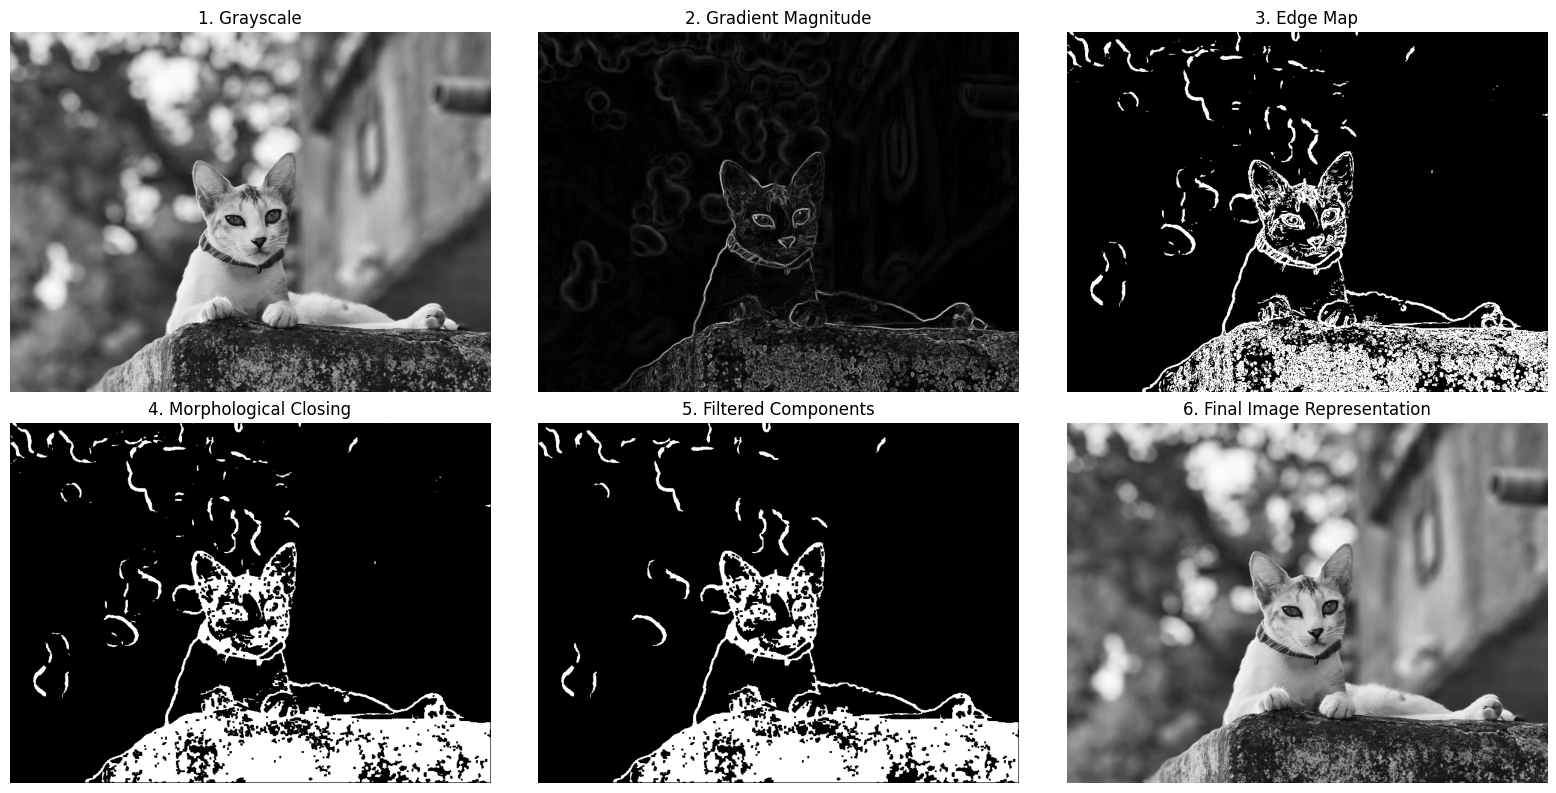

In [ ]:

plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.imshow(results["gray"], cmap="gray")
plt.title("1. Grayscale")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(results["gradient"], cmap="gray")
plt.title("2. Gradient Magnitude")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(results["edges"], cmap="gray")
plt.title("3. Edge Map")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(results["closed_edges"], cmap="gray")
plt.title("4. Morphological Closing")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(results["labels"] > 0, cmap="gray")
plt.title("5. Filtered Components")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(results["gray"], cmap="gray")
plt.title("6. Final Image Representation")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:

# Get the final component labels
final_labels = results["labels"]

# Find component sizes
final_sizes = np.bincount(final_labels.ravel())

# Build feature table
final_features = []

for label in range(1, len(final_sizes)):

    area = final_sizes[label]

    if area == 0:
        continue

    coords = np.argwhere(final_labels == label)

    y_coords = coords[:, 0]
    x_coords = coords[:, 1]

    centroid_x = x_coords.mean()
    centroid_y = y_coords.mean()

    x_min, x_max = x_coords.min(), x_coords.max()
    y_min, y_max = y_coords.min(), y_coords.max()

    width = x_max - x_min + 1
    height = y_max - y_min + 1

    aspect_ratio = width / height

    final_features.append({
        "Label": label,
        "Area": area,
        "Centroid X": round(centroid_x, 2),
        "Centroid Y": round(centroid_y, 2),
        "Width": width,
        "Height": height,
        "Aspect Ratio": round(aspect_ratio, 3)
    })

final_df = pd.DataFrame(final_features)

final_df = final_df.sort_values(
    "Area",
    ascending=False
).reset_index(drop=True)

print("FINAL IMAGE ANALYSIS REPORT")
print("=" * 40)
print("Image dimensions:", results["gray"].shape)
print("Components detected:", len(final_df))
print()
print("Largest components:")
display(final_df.head(10))

FINAL IMAGE ANALYSIS REPORT
Image dimensions: (600, 800)
Components detected: 27

Largest components:


,Label,Area,Centroid X,Centroid Y,Width,Height,Aspect Ratio
0,73,71253,474.73,493.28,674,399,1.689
1,41,557,213.80,109.75,48,84,0.571
2,65,527,406.34,182.58,29,77,0.377
3,111,498,192.65,339.38,58,52,1.115
4,91,389,235.35,264.48,40,50,0.800
5,129,386,48.52,429.83,22,52,0.423
6,8,379,103.25,43.19,55,54,1.019
7,64,346,371.97,178.55,24,73,0.329
8,7,277,29.30,28.26,27,44,0.614
9,173,221,312.50,570.33,24,25,0.960


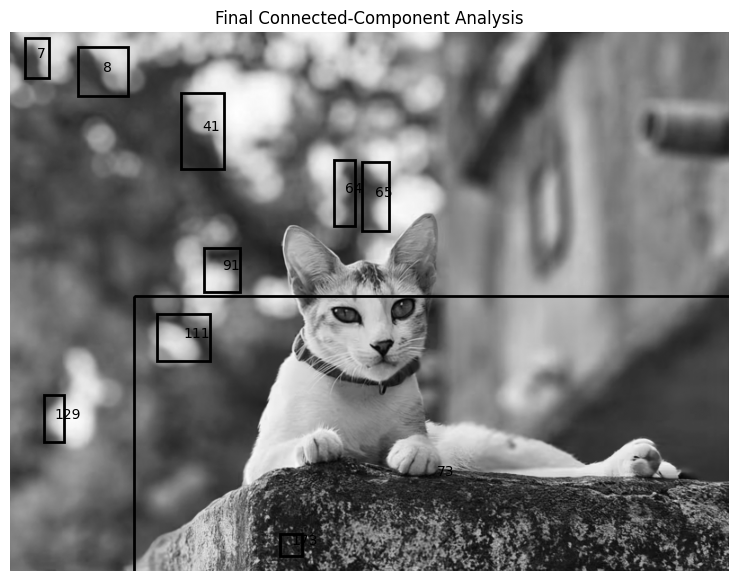

In [ ]:

fig, ax = plt.subplots(figsize=(10, 7))

ax.imshow(results["gray"], cmap="gray")

for _, row in final_df.head(10).iterrows():

    x = row["Centroid X"]
    y = row["Centroid Y"]

    width = row["Width"]
    height = row["Height"]

    x_min = x - width / 2
    y_min = y - height / 2

    rectangle = plt.Rectangle(
        (x_min, y_min),
        width,
        height,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rectangle)

    ax.text(
        x,
        y,
        str(int(row["Label"])),
        fontsize=10
    )

ax.set_title("Final Connected-Component Analysis")
ax.axis("off")

plt.show()

In [ ]:

thresholds = [50, 80, 120]

validation_results = []

for T in thresholds:

    result = image_analysis_pipeline(
        img_array,
        edge_threshold=T,
        min_component_size=100
    )

    labels = result["labels"]

    component_count = len(
        np.unique(labels)
    ) - 1

    validation_results.append({
        "Edge Threshold": T,
        "Components": component_count
    })

validation_df = pd.DataFrame(validation_results)

display(validation_df)

,Edge Threshold,Components
0,50,30
1,80,27
2,120,8


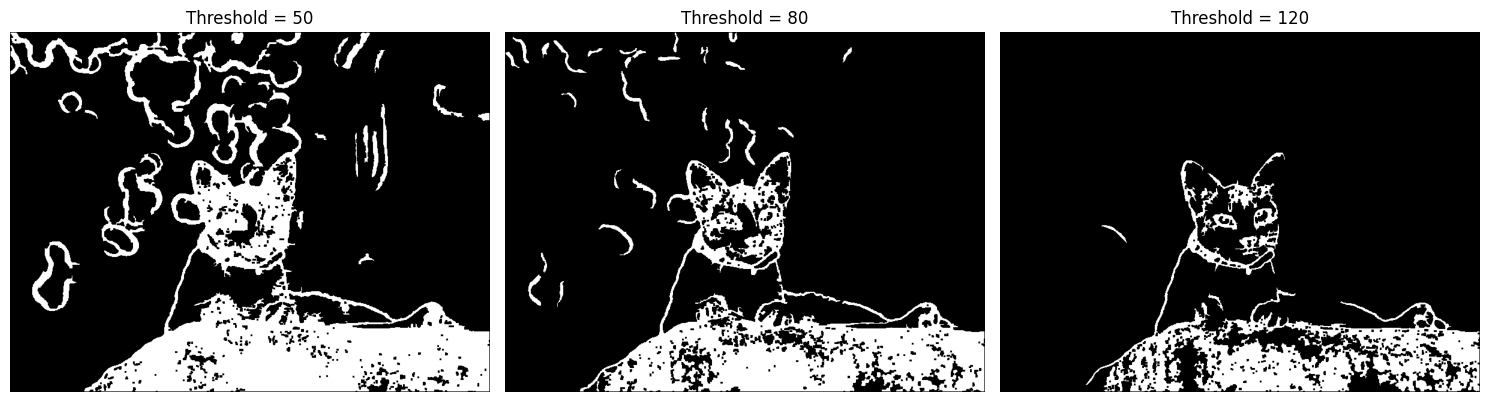

In [ ]:

plt.figure(figsize=(15, 5))

for i, T in enumerate(thresholds):

    result = image_analysis_pipeline(
        img_array,
        edge_threshold=T,
        min_component_size=100
    )

    plt.subplot(1, 3, i + 1)
    plt.imshow(result["labels"] > 0, cmap="gray")
    plt.title(f"Threshold = {T}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:

import time

sizes = [
    (400, 300),
    (800, 600),
    (1200, 900)
]

timing_results = []

for width, height in sizes:

    test_image = Image.fromarray(
        img_array
    ).resize((width, height))

    test_array = np.array(test_image)

    start = time.perf_counter()

    _ = image_analysis_pipeline(
        test_array,
        edge_threshold=80,
        min_component_size=100
    )

    elapsed = time.perf_counter() - start

    timing_results.append({
        "Width": width,
        "Height": height,
        "Pixels": width * height,
        "Time (seconds)": round(elapsed, 3)
    })

timing_df = pd.DataFrame(timing_results)

display(timing_df)

,Width,Height,Pixels,Time (seconds)
0,400,300,120000,22.476
1,800,600,480000,20.540
2,1200,900,1080000,23.458


In [ ]:

import time

test_sizes = [
    (100, 100),
    (200, 200),
    (300, 300),
    (400, 400)
]

complexity_results = []

for width, height in test_sizes:

    test_image = np.array(
        Image.fromarray(img_array)
        .convert("L")
        .resize((width, height))
    )

    start = time.perf_counter()

    _ = apply_kernel(
        test_image,
        sobel_x
    )

    elapsed = time.perf_counter() - start

    complexity_results.append({
        "Width": width,
        "Height": height,
        "Pixels": width * height,
        "Time (seconds)": round(elapsed, 4)
    })

complexity_df = pd.DataFrame(complexity_results)

display(complexity_df)

,Width,Height,Pixels,Time (seconds)
0,100,100,10000,0.0711
1,200,200,40000,0.3180
2,300,300,90000,0.6622
3,400,400,160000,1.2312


In [ ]:

complexity_df["Time per Pixel (µs)"] = (
    complexity_df["Time (seconds)"]
    / complexity_df["Pixels"]
    * 1_000_000
)

display(complexity_df)

,Width,Height,Pixels,Time (seconds),Time per Pixel (µs)
0,100,100,10000,0.0711,7.110000
1,200,200,40000,0.3180,7.950000
2,300,300,90000,0.6622,7.357778
3,400,400,160000,1.2312,7.695000


In [ ]:

final_summary = {
    "Image dimensions": results["gray"].shape,
    "Otsu threshold": otsu_T,
    "Initial edge components": num_components,
    "Components after dilation": dilated_count,
    "Largest segmented region": int(seg_sizes[1:].max()),
    "Final analyzed components": len(final_df),
    "Edge threshold tested": [50, 80, 120],
    "Complexity": "O(H × W) for fixed 3×3 kernel"
}

for key, value in final_summary.items():
    print(f"{key}: {value}")

Image dimensions: (600, 800)
Otsu threshold: 122
Initial edge components: 571
Components after dilation: 114
Largest segmented region: 183794
Final analyzed components: 27
Edge threshold tested: [50, 80, 120]
Complexity: O(H × W) for fixed 3×3 kernel


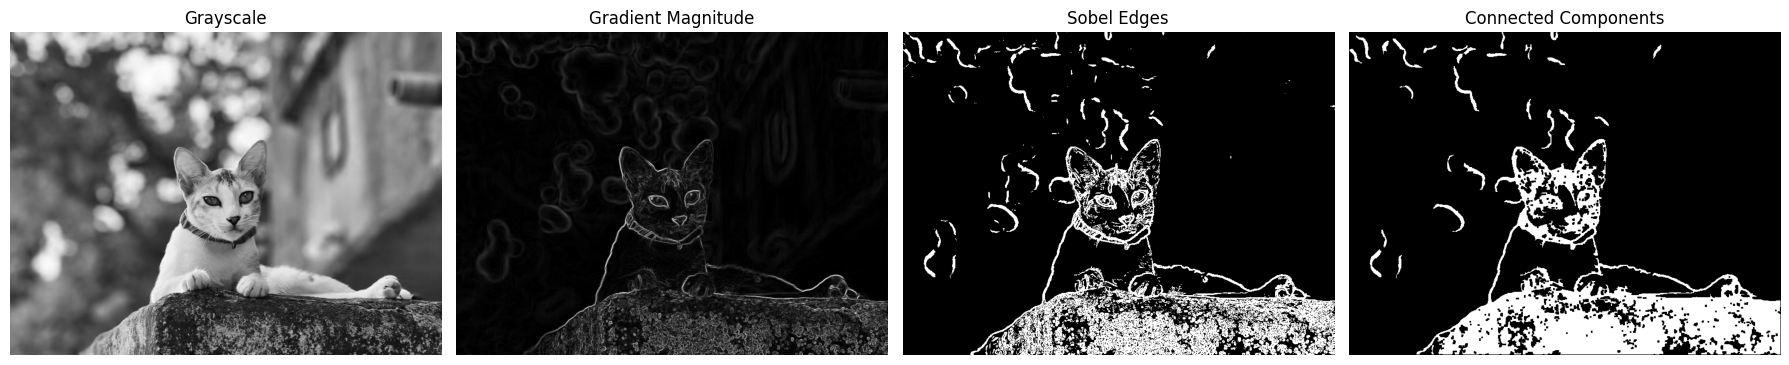

In [ ]:

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(results["gray"], cmap="gray")
axes[0].set_title("Grayscale")

axes[1].imshow(results["gradient"], cmap="gray")
axes[1].set_title("Gradient Magnitude")

axes[2].imshow(results["edges"], cmap="gray")
axes[2].set_title("Sobel Edges")

axes[3].imshow(results["labels"] > 0, cmap="gray")
axes[3].set_title("Connected Components")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Final Results

The complete pipeline successfully transforms the original RGB image into
several mathematical representations:

1. Grayscale intensity matrix
2. Gradient magnitude field
3. Binary Sobel edge map
4. Morphologically processed edge map
5. Connected-component representation
6. Geometric and shape descriptors

The final pipeline demonstrates how local pixel operations can produce
higher-level geometric information from a digital image.

## Limitations and Observations

The methods implemented in this project are classical image-processing
techniques and do not perform semantic object recognition.

In particular:

- Edge detection identifies intensity transitions, not objects.
- Connected components identify mathematical connectivity, not semantic entities.
- Global thresholding can fail when foreground and background intensities overlap.
- Morphological operations are sensitive to the choice of structuring element.
- The perimeter calculation is a pixel-grid approximation.
- Direct Python implementations of convolution and morphology are
  computationally expensive for high-resolution images.

These limitations demonstrate the distinction between low-level image
processing and semantic computer vision.

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import os
from PIL import Image

filename = next(iter(uploaded))
image.save("/content/drive/MyDrive/" + filename)

print("Saved permanently as:", filename)

Saved permanently as: cat.jpg


## Recovery and Reproducibility Checkpoint

The complete image-processing pipeline was successfully reconstructed
after a runtime reset using the original input image.

The recovered results were verified against the previously recorded
values:

- Working image dimensions: 600 × 800
- Otsu threshold: 122
- Initial edge components: 571
- Components after dilation: 114
- Largest segmented region: 183,794 pixels
- Edge thresholds tested: 50, 80, 120
- Convolution complexity for a fixed 3×3 kernel: O(H × W)

The original input image has also been saved permanently to Google Drive
as `cat.jpg` to improve reproducibility across Colab runtime sessions.

## Mathematical Interpretation

The image-processing pipeline can be interpreted as a sequence of
mathematical transformations on discrete functions.

A grayscale image is represented as a function

$$
I:\Omega \rightarrow \mathbb{R},
$$

where $\Omega$ is a finite two-dimensional pixel grid.

The major transformations are:

1. **Grayscale conversion**

$$
Y = 0.299R + 0.587G + 0.114B
$$

2. **Discrete filtering**

$$
I'(x,y)=\sum_i\sum_j K(i,j)I(x+i,y+j)
$$

3. **Discrete derivatives**

$$
G_x = K_x * I,\qquad
G_y = K_y * I
$$

4. **Gradient magnitude**

$$
|\nabla I| =
\sqrt{G_x^2+G_y^2}
$$

5. **Thresholding**

$$
E(x,y)=
\begin{cases}
1,&|\nabla I(x,y)|>T\\
0,&\text{otherwise}
\end{cases}
$$

6. **Morphological transformation**

Dilation and erosion modify the binary set according to a
structuring element.

7. **Connected-component analysis**

The binary image is interpreted as a graph of connected pixels,
allowing individual connected regions to be identified.

8. **Geometric analysis**

Each region can then be described using quantities such as area,
centroid, bounding-box dimensions, aspect ratio, perimeter, and
circularity.

Thus, the complete process transforms a high-dimensional array of
pixel intensities into increasingly structured mathematical
representations.

## Results and Discussion

The implemented pipeline successfully transformed the original RGB
image into several mathematically meaningful representations.

### Key results

- Original image dimensions: 2676 × 3568 × 3
- Working grayscale image: 600 × 800
- Otsu threshold: 122
- Initial connected edge components: 571
- Components after dilation: 114
- Largest segmented region: 183,794 pixels
- Edge thresholds investigated: 50, 80, and 120

### Observations

The Sobel operator successfully highlighted regions of rapid intensity
variation. Increasing the edge threshold removed weaker gradients and
retained only stronger intensity transitions.

Morphological dilation connected nearby edge structures and altered
the topology of the binary representation. This demonstrates that
morphological operations can significantly affect connected-component
structure.

Otsu thresholding automatically selected a global threshold of 122
from the grayscale intensity distribution. The resulting segmentation
captured large intensity-based regions, but it did not correspond
perfectly to semantic objects.

The connected-component and geometric analyses demonstrated how a
binary image can be converted into quantitative spatial information,
including area, centroid, bounding-box dimensions, aspect ratio,
perimeter, and circularity.

Overall, the experiment demonstrates that a digital image can be
studied as a discrete mathematical object rather than only as a
visual photograph.

## Full Mathematical Pipeline

The complete workflow can be summarized as

$$
\mathrm{RGB}
\rightarrow
\mathrm{Grayscale}
\rightarrow
\mathrm{Filtering}
\rightarrow
\mathrm{Sobel}
\rightarrow
\mathrm{Gradient\ Magnitude}
\rightarrow
\mathrm{Thresholding}
\rightarrow
\mathrm{Morphology}
\rightarrow
\mathrm{Connected\ Components}
\rightarrow
\mathrm{Geometric\ Features}
$$

Mathematically, the pipeline consists of the following transformations:

$$
(R,G,B)\rightarrow I
$$

followed by discrete filtering,

$$
I\rightarrow I*K,
$$

discrete differentiation,

$$
I\rightarrow(G_x,G_y),
$$

and gradient magnitude,

$$
(G_x,G_y)\rightarrow
\sqrt{G_x^2+G_y^2}.
$$

A threshold then converts the continuous-valued gradient field into
a binary representation,

$$
|\nabla I|\rightarrow E.
$$

Morphological operators modify the binary structure, after which
connected-component analysis identifies connected regions.

Finally, each region is represented using geometric quantities such as

$$
A,\quad
(x_c,y_c),\quad
W,\quad
H,\quad
\frac{W}{H},\quad
P,\quad
\frac{4\pi A}{P^2}.
$$

Therefore, the project forms a complete chain from raw pixel
measurements to quantitative geometric descriptions.

## Conclusion

This project investigated digital image processing from a mathematical
perspective using only fundamental computational tools.

An image was represented as a discrete numerical function, and a
sequence of mathematical operations was implemented to transform that
representation. These included grayscale conversion, discrete
filtering, finite-difference gradients, Sobel edge detection,
thresholding, mathematical morphology, connected-component analysis,
and geometric feature extraction.

The experiments demonstrated that relatively simple mathematical
operations can produce increasingly structured descriptions of visual
data.

The project also examined parameter sensitivity and computational
complexity. In particular, direct implementation of a fixed-size
convolution kernel has computational complexity

$$
O(HW)
$$

with respect to the image dimensions $H$ and $W$.

The work highlights the connection between linear algebra, discrete
calculus, set-based morphology, graph connectivity, and geometry in
digital image analysis.

It also illustrates an important distinction between mathematical
image processing and semantic computer vision: the methods implemented
here analyse numerical and structural properties of an image without
requiring knowledge of what the image represents.